In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Advertising.csv to Advertising (1).csv


In [3]:
df = pd.read_csv("Advertising.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
correlation = df.corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
            Unnamed: 0        TV     Radio  Newspaper     Sales
Unnamed: 0    1.000000  0.017715 -0.110680  -0.154944 -0.051616
TV            0.017715  1.000000  0.054809   0.056648  0.782224
Radio        -0.110680  0.054809  1.000000   0.354104  0.576223
Newspaper    -0.154944  0.056648  0.354104   1.000000  0.228299
Sales        -0.051616  0.782224  0.576223   0.228299  1.000000


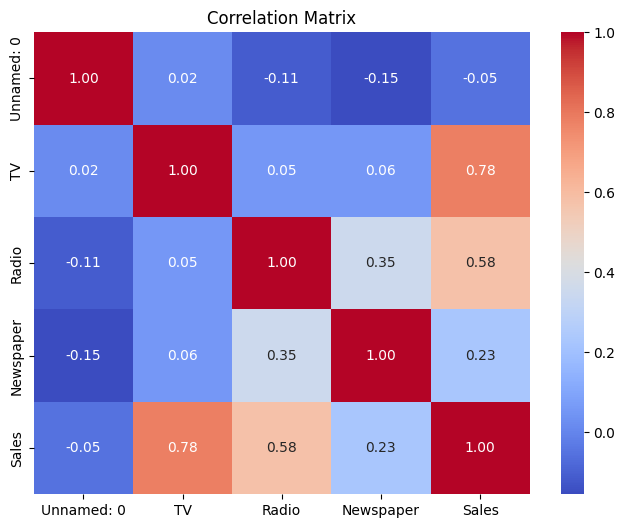

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

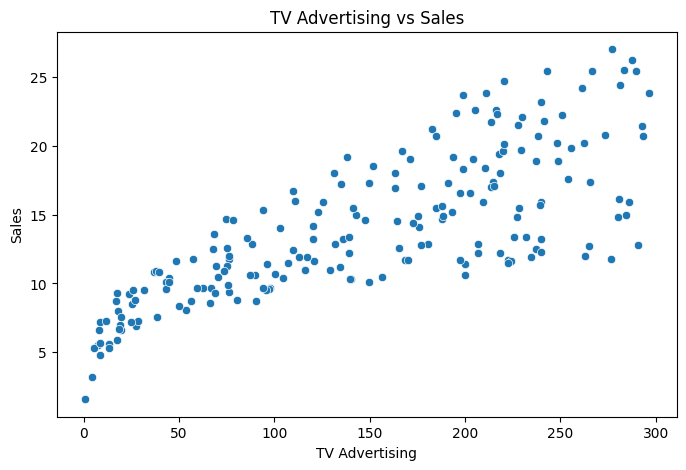

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.show()

In [11]:
X = df[["TV"]]
y = df["Sales"]

print("Independent Variable: TV")
print("Dependent Variable: Sales")

Independent Variable: TV
Dependent Variable: Sales


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 160
Testing data: 40


In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [14]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

print(
    "\nRegression Equation:")
print(
    "Sales =",
    model.intercept_,
    "+",
    model.coef_[0],
    "* TV"
)

Intercept: 7.119638430592953
Coefficient: 0.046529733705443346

Regression Equation:
Sales = 7.119638430592953 + 0.046529733705443346 * TV


In [15]:
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred)

Predicted Sales:
[14.71794394 16.2115484  20.74819743  7.66403631 17.37013877 10.61402143
 17.2072847   9.44612512 17.46785121 15.2669948   8.58532504  9.73460946
 18.03086098  7.37089899 13.61053628 15.03899911  7.45930549 16.31391381
 10.62332738 18.16579721 17.79821232 10.27435438  8.88776831 18.79394862
 10.33019006  9.60897918 17.05373658 13.60123034 11.17703121  7.51048819
 16.41627922 10.339496   16.37440246  7.90599093 20.18053468 18.203021
  9.36702457 19.85482655 12.57292322  8.39920611]


In [16]:
result = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print(result)

    Actual Sales  Predicted Sales
0           16.9        14.717944
1           22.4        16.211548
2           21.4        20.748197
3            7.3         7.664036
4           24.7        17.370139
5           12.6        10.614021
6           22.3        17.207285
7            8.4         9.446125
8           11.5        17.467851
9           14.9        15.266995
10           9.5         8.585325
11           8.7         9.734609
12          11.9        18.030861
13           5.3         7.370899
14          10.3        13.610536
15          11.7        15.038999
16           5.5         7.459305
17          16.6        16.313914
18          11.3        10.623327
19          18.9        18.165797
20          19.7        17.798212
21          12.5        10.274354
22          10.9         8.887768
23          22.2        18.793949
24           9.3        10.330190
25           8.1         9.608979
26          21.7        17.053737
27          13.4        13.601230
28          10

In [17]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6766954295627076


In [18]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 10.204654118800956


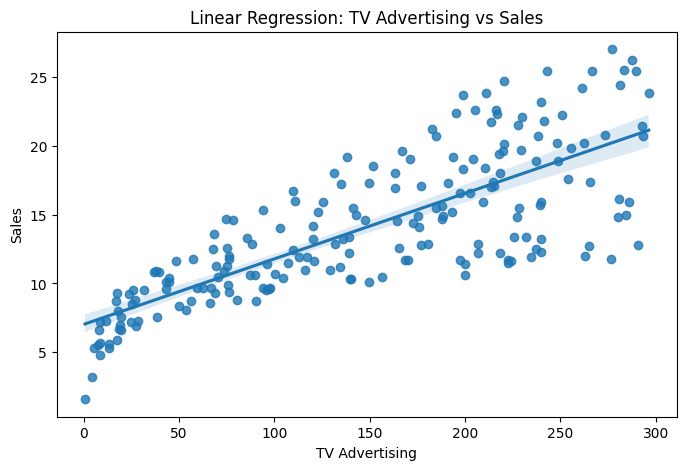

In [19]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("Linear Regression: TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.show()